# SpikingMamba
Author: Donald Scheuring

# Introduction

This notebook demonstrates a model architecture that combines concepts from two main sources:

1. **Mamba (Selective State Space Models)**: An architecture that leverages state space models (SSMs) for sequence modeling, originally introduced to handle very long sequences efficiently. Mamba incorporates selection mechanisms that let the model focus on relevant parts of the input sequence dynamically, improving modeling capabilities over naive linear-time methods.

2. **P-SpikeSSM (Probabilistic Spiking State-Space Models)**: A framework that replaces traditional LIF neurons with a stochastic spike generation mechanism based on SSMs. This allows us to model sequences via spike probabilities and efficiently train using surrogate gradients, enabling parallelization and scalability.

Our goal is to integrate the P-SpikeSSM-style stochastic spiking and surrogate gradients into a Mamba-like architecture. The final model, which we call "SpikingMamba," attempts to offer both the efficiency and long-range modeling capabilities of Mamba and the biologically-inspired, energy-efficient spiking framework of P-SpikeSSM.

## Architectural Overview

**Mamba** is built on the idea of Structured State Space Models (SSMs). SSMs define a linear recurrence that can be computed efficiently either via recurrence or a convolution-like approach. Mamba extends these SSMs by adding an input-dependent selection mechanism, allowing the model to choose which parts of the input to retain. This selective SSM can model complex dependencies and ignore irrelevant inputs, effectively compressing contextual information.

**P-SpikeSSM** introduces a parallelizable, probabilistic spike generation model based on SSM principles. Instead of LIF neurons that update states sequentially and deterministically, P-SpikeSSM generates spikes from probabilities using a surrogate gradient method. This approach maintains SNN-like energy efficiency and parallelizability while simplifying training (no BPTT required).

## Combining Mamba and P-SpikeSSM

**Mamba** uses Structured State Space Models (SSMs) that can be computed efficiently via recurrences or convolutions. It introduces selectivity: the SSM parameters vary with the input, enabling dynamic context filtering.

**P-SpikeSSM** introduces a parallelizable, probabilistic spike generation mechanism from SSM outputs, along with surrogate gradients for training. This eliminates the sequential bottleneck of traditional LIF neurons and simplifies training.

We combine these ideas:
- **SSM (NPLR-based from S4)** provides stable long-range memory.
- **Probabilistic Spikes** (P-SpikeSSM) enable parallel, biologically plausible spike computation.
- **Selection Mechanism (from Mamba)** ensures input-dependent parameters that allow the model to ignore irrelevant inputs and focus on what matters for long-range tasks.


This combined approach aims to achieve stable, accurate long-range performance. We use NPLR (Normal+Low-Rank) parameterization from S4 to stabilize and efficiently parameterize the SSM, and we incorporate SpikeSampler and surrogate gradients from P-SpikeSSM to train the network with probabilistic spikes.


# Research Goals

The code presented combines Mamba’s selective SSM concept with P-SpikeSSM’s probabilistic spiking and scaling techniques. We have integrated:
- A selective mechanism in the SSM (Mamba feature).
- A probabilistic spike generation approach with surrogate gradients (P-SpikeSSM feature).
- Parallel scan algorithms for efficient training.
- A simplified block structure that merges MLP and SSM operations in a Mamba-like fashion.

This architecture should, in principle, handle long-range dependencies more efficiently than standard spiking or SSM-only models and should be capable of achieving performance close to that of state-of-the-art methods. By setting hyperparameters (like `use_probabilistic_spikes=True`), we can toggle between more P-SpikeSSM-like behavior (probabilistic spikes) or deterministic spiking if desired.


In [ ]:
!pip install --quiet evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 18.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


#Spiking Mamba


This is the code for a model architecture called Spiking Mamba.
This architecture combines Mamba with spiking characteristics of P-SpikeSSM.

We have added extensive documentation and annotations in order to make our implementation as understandable as possible.

# The Model

## Parallel Scan

These Parallel Scan functions were taken from [this Mamba implementation](https://github.com/alxndrTL/mamba.py), all credit for these goes to the original implementation.

In [ ]:
import math
import torch
import torch.nn.functional as F


def npo2(len):
    """
    returns the next power of 2 above len
    """

    return 2 ** math.ceil(math.log2(len))

def pad_npo2(X):
    """
    pads input length dim to the next power of 2
    """

    len_npo2 = npo2(X.size(1))
    pad_tuple = (0, 0, 0, 0, 0, len_npo2 - X.size(1))
    return F.pad(X, pad_tuple, "constant", 0)

class PScan(torch.autograd.Function):
    @staticmethod
    def pscan(A, X):
        B, D, L, _ = A.size()
        num_steps = int(math.log2(L))

        #up sweep
        Aa = A
        Xa = X
        for _ in range(num_steps-2):
            T = Xa.size(2)
            Aa = Aa.view(B, D, T//2, 2, -1)
            Xa = Xa.view(B, D, T//2, 2, -1)

            Xa[:, :, :, 1].add_(Aa[:, :, :, 1].mul(Xa[:, :, :, 0]))
            Aa[:, :, :, 1].mul_(Aa[:, :, :, 0])

            Aa = Aa[:, :, :, 1]
            Xa = Xa[:, :, :, 1]

        if Xa.size(2) == 4:
            Xa[:, :, 1].add_(Aa[:, :, 1].mul(Xa[:, :, 0]))
            Aa[:, :, 1].mul_(Aa[:, :, 0])

            Xa[:, :, 3].add_(Aa[:, :, 3].mul(Xa[:, :, 2] + Aa[:, :, 2].mul(Xa[:, :, 1])))
        elif Xa.size(2) == 2:
            Xa[:, :, 1].add_(Aa[:, :, 1].mul(Xa[:, :, 0]))
            return
        else:
            return

        #down sweep
        Aa = A[:, :, 2**(num_steps-2)-1:L:2**(num_steps-2)]
        Xa = X[:, :, 2**(num_steps-2)-1:L:2**(num_steps-2)]
        Xa[:, :, 2].add_(Aa[:, :, 2].mul(Xa[:, :, 1]))
        Aa[:, :, 2].mul_(Aa[:, :, 1])

        for k in range(num_steps-3, -1, -1):
            Aa = A[:, :, 2**k-1:L:2**k]
            Xa = X[:, :, 2**k-1:L:2**k]

            T = Xa.size(2)
            Aa = Aa.view(B, D, T//2, 2, -1)
            Xa = Xa.view(B, D, T//2, 2, -1)

            Xa[:, :, 1:, 0].add_(Aa[:, :, 1:, 0].mul(Xa[:, :, :-1, 1]))
            Aa[:, :, 1:, 0].mul_(Aa[:, :, :-1, 1])

    @staticmethod
    def pscan_rev(A, X):
        B, D, L, _ = A.size()
        num_steps = int(math.log2(L))

        #up sweep
        Aa = A
        Xa = X
        for _ in range(num_steps-2):
            T = Xa.size(2)
            Aa = Aa.view(B, D, T//2, 2, -1)
            Xa = Xa.view(B, D, T//2, 2, -1)

            Xa[:, :, :, 0].add_(Aa[:, :, :, 0].mul(Xa[:, :, :, 1]))
            Aa[:, :, :, 0].mul_(Aa[:, :, :, 1])

            Aa = Aa[:, :, :, 0]
            Xa = Xa[:, :, :, 0]

        if Xa.size(2) == 4:
            Xa[:, :, 2].add_(Aa[:, :, 2].mul(Xa[:, :, 3]))
            Aa[:, :, 2].mul_(Aa[:, :, 3])

            Xa[:, :, 0].add_(Aa[:, :, 0].mul(Xa[:, :, 1].add(Aa[:, :, 1].mul(Xa[:, :, 2]))))
        elif Xa.size(2) == 2:
            Xa[:, :, 0].add_(Aa[:, :, 0].mul(Xa[:, :, 1]))
            return
        else:
            return

        #down sweep
        Aa = A[:, :, 0:L:2**(num_steps-2)]
        Xa = X[:, :, 0:L:2**(num_steps-2)]
        Xa[:, :, 1].add_(Aa[:, :, 1].mul(Xa[:, :, 2]))
        Aa[:, :, 1].mul_(Aa[:, :, 2])

        for k in range(num_steps-3, -1, -1):
            Aa = A[:, :, 0:L:2**k]
            Xa = X[:, :, 0:L:2**k]

            T = Xa.size(2)
            Aa = Aa.view(B, D, T//2, 2, -1)
            Xa = Xa.view(B, D, T//2, 2, -1)

            Xa[:, :, :-1, 1].add_(Aa[:, :, :-1, 1].mul(Xa[:, :, 1:, 0]))
            Aa[:, :, :-1, 1].mul_(Aa[:, :, 1:, 0])

    @staticmethod
    def forward(ctx, A_in, X_in):
        """
        applies the parallel scan operation
        """

        L = X_in.size(1)

        # cloning is requiered because of the in-place ops
        if L == npo2(L):
            A = A_in.clone()
            X = X_in.clone()
        else:
            # pad tensors (and clone btw)
            A = pad_npo2(A_in) # (B, npo2(L), D, N)
            X = pad_npo2(X_in) # (B, npo2(L), D, N)

        # prepare tensors
        A = A.transpose(2, 1) # (B, D, npo2(L), N)
        X = X.transpose(2, 1) # (B, D, npo2(L), N)

        # parallel scan (modifies X in-place)
        PScan.pscan(A, X)

        ctx.save_for_backward(A_in, X)

        # slice [:, :L] (cut if there was padding)
        return X.transpose(2, 1)[:, :L]

    @staticmethod
    def backward(ctx, grad_output_in):
        """
        flows gradient from the output to the input
        """

        A_in, X = ctx.saved_tensors

        L = grad_output_in.size(1)

        if L == npo2(L):
            grad_output = grad_output_in.clone()
        else:
            grad_output = pad_npo2(grad_output_in)
            A_in = pad_npo2(A_in)

        grad_output = grad_output.transpose(2, 1)
        A_in = A_in.transpose(2, 1)
        A = torch.nn.functional.pad(A_in[:, :, 1:], (0, 0, 0, 1))
        PScan.pscan_rev(A, grad_output)

        Q = torch.zeros_like(X)
        Q[:, :, 1:].add_(X[:, :, :-1] * grad_output[:, :, 1:])

        return Q.transpose(2, 1)[:, :L], grad_output.transpose(2, 1)[:, :L]

pscan = PScan.apply

## Config

In [ ]:
import math
from dataclasses import dataclass, asdict
from typing import Union

import torch
import torch.nn as nn
import torch.nn.functional as F

@dataclass
class MambaConfig:
    """
    configuration for both Mamba and SpikingMamba models

    attributes (from Mamba):
        d_model: Model dimension (D)
        n_layers: Number of residual blocks
        dt_rank: Rank for delta parameterization; can be 'auto'
        d_state: State dimension (N)
        expand_factor: Expansion factor (E) for intermediate dimension ED = E*D
        d_conv: Kernel size for the small depthwise convolution.

        dt_min, dt_max, dt_init, dt_scale, dt_init_floor: Parameters controlling delta initialization
        rms_norm_eps: Epsilon for RMSNorm
        base_std: Base standard deviation for initialization
        bias, conv_bias: Whether to use bias in linear/conv layers
        inner_layernorms: Whether to apply layernorm to internal vectors (delta, B, C)
        mup: Whether to use muP scaling
        mup_base_width: Base width used for muP scaling
        pscan: If True, use parallel scan mode; if False, use sequential scan
        use_cuda: If True, attempt to use CUDA-optimized selective scan

        input_dim:  adding task
        output_dim: for adding task: 1, for pSMNIST: 10 classes

    additional attributes for spiking modifications:
        spiking_probability_mode: "linear" or "sigmoid" - how to convert continuous outputs to spike probabilities
        use_fuse_clamp: Boolean, whether to use the FuseClamp layer after mixing spikes
    """
    d_model: int
    n_layers: int
    dt_rank: Union[int, str] = 'auto'
    d_state: int = 16
    expand_factor: int = 2
    d_conv: int = 4

    dt_min: float = 0.001
    dt_max: float = 0.1
    dt_init: str = "random"
    dt_scale: float = 1.0
    dt_init_floor = 1e-4

    rms_norm_eps: float = 1e-5
    base_std: float = 0.02

    bias: bool = False
    conv_bias: bool = True
    inner_layernorms: bool = False
    mup: bool = False
    mup_base_width: float = 128

    pscan: bool = True
    use_cuda: bool = True

    input_dim: int = 2
    output_dim: int = 1
    spiking_probability_mode: str = "linear"
    use_fuse_clamp: bool = False

    def __post_init__(self):
        self.d_inner = self.expand_factor * self.d_model
        if self.dt_rank == 'auto':
            self.dt_rank = math.ceil(self.d_model / 16)
        if self.mup:
            self.mup_width_mult = self.d_model / self.mup_base_width

    def to_dict(self):
        return asdict(self)

    def to_json_string(self):
        return json.dumps(self.to_dict(), indent=2, sort_keys=True)


## P-SpikeSSM Classes

### SpikeSampler

Converts continuous probabilities into discrete spike events while preserving differentiability through a surrogate gradient trick.


Given a probability tensor $p \in [0,1]$, it samples spikes from a Bernoulli distribution. During the forward pass it uses the sampled binary values as output, but during backward passes it replaces the non-differentiable step with a surrogate gradient equal to the identity, allowing gradients to flow through the probabilistic sampling step.

In [ ]:
class SpikeSampler(nn.Module):
    """
    convert probabilities [0,1] into spikes using bernoulli sampling
    surrogate gradient is used so that during backward
    """
    def forward(self, ps):
        with torch.no_grad():
            spikes = torch.bernoulli(ps)
        return spikes + (ps - ps.detach())

### SpikeMixer

Enables inter-neuron communication and interaction among spike trains from different neurons.

After the SpikeSampler produces spikes for each neuron, the SpikeMixer applies a linear transformation (and a nonlinearity like GELU) across the neuron dimension. This effectively mixes information between neurons, allowing the population of neurons to combine their spiking patterns and achieve richer representations.

In [ ]:
class SpikeMixer(nn.Module):
    """
    mix spikes across neurons
    this applies a linear transform followed by GELU
    """
    def __init__(self, n_neurons):
        super().__init__()
        self.mix = nn.Linear(n_neurons, n_neurons, bias=False)

    def forward(self, spikes):
        return F.gelu(self.mix(spikes))

### FuseClamp

 Stabilizes and normalizes the mixed spike signals to ensure they remain within a valid probability range and can be fed into subsequent processing stages.

FuseClamp takes the outputs from the SpikeMixer and fuses them with the previous spike inputs before applying a normalization layer and clamping the results between $[0,1]$. This ensures that outputs remain well-behaved probabilities suitable for further spike sampling or downstream computations.


In [ ]:
class FuseClamp(nn.Module):
    """
    fuse output with input spikes and clamp [0,1]
    - Add mixed spikes to input spikes
    - Apply normalization
    - Clamp result to [0,1]
    """
    def __init__(self, d_inner):
        super().__init__()
        self.bn = nn.LayerNorm(d_inner)

    def forward(self, mixer_output, input_spikes):
        fused = mixer_output + input_spikes
        fused = self.bn(fused)
        fused = torch.clamp(fused, 0, 1)
        return fused

## Mamba Architecture

### RMSNorm

Normalizes the representation to stabilize training and maintain scale-invariance.

RMSNorm normalizes vectors based on their root mean square value. It ensures that the scale of the intermediate features remains consistent, improving training stability and allowing the model to benefit from well-calibrated activations.

In [ ]:
class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-5, use_mup: bool = False):
        super().__init__()
        self.use_mup = use_mup
        self.eps = eps
        if not use_mup:
            self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        output = x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        if not self.use_mup:
            return output * self.weight
        else:
            return output

### ResidualBlock


In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, config: MambaConfig, block_cls=None):
        super().__init__()
        if block_cls is None:
            block_cls = SpikingMambaBlock
        self.mixer = block_cls(config)
        self.norm = RMSNorm(config.d_model, config.rms_norm_eps, config.mup)

    def forward(self, x):
        return self.mixer(self.norm(x)) + x

### SpikingMambaBlock

fundamental building block of the model’s architecture, providing both nonlinear transformations and a residual connection to promote stable and efficient training

SpikingMamba assembles multiple ResidualBlocks (each containing SpikingMambaBlocks), applies spike generation and mixing, and leverages state space computations internally. The model takes either raw inputs (converted to spikes by the InputSpikeEncoder) or continuous inputs (if not using the encoder), and iteratively transforms them through a stack of layers until a final representation is produced. The classification head then aggregates these representations (eg, via pooling) to generate the final outputs

In [ ]:
class SpikingMambaBlock(nn.Module):
    """
    Mamba block with spiking

    Derivation:
    - just like normal Mamba:
      * Input split into x,z
      * x -> conv -> ssm to produce y
      * z used as a gating signal (originally y * silu(z))
    - from P-SPIKESSM:
      * Convert y,z to probabilities, sample spikes
      * Gating in spike domain: y_spikes * z_spikes
      * pass through SpikeMixer, optional FuseClamp
    """
    def __init__(self, config: MambaConfig):
        super().__init__()
        self.config = config
        self.in_proj = nn.Linear(config.d_model, 2*config.d_inner, bias=config.bias)
        self.conv1d = nn.Conv1d(config.d_inner, config.d_inner, kernel_size=config.d_conv, bias=config.conv_bias,
                                groups=config.d_inner, padding=config.d_conv-1)
        self.x_proj = nn.Linear(config.d_inner, config.dt_rank + 2*config.d_state, bias=False)
        self.dt_proj = nn.Linear(config.dt_rank, config.d_inner, bias=True)

        dt_init_std = config.dt_rank**-0.5 * config.dt_scale
        if config.dt_init == "constant":
            nn.init.constant_(self.dt_proj.weight, dt_init_std)
        else:
            nn.init.uniform_(self.dt_proj.weight, -dt_init_std, dt_init_std)

        dt = torch.exp(
            torch.rand(config.d_inner)*(math.log(config.dt_max)-math.log(config.dt_min)) + math.log(config.dt_min)
        ).clamp(min=config.dt_init_floor)
        inv_dt = dt + torch.log(-torch.expm1(-dt))
        with torch.no_grad():
            self.dt_proj.bias.copy_(inv_dt)

        A = torch.arange(1, config.d_state+1, dtype=torch.float32).repeat(config.d_inner,1)
        self.A_log = nn.Parameter(torch.log(A))
        self.A_log._no_weight_decay = True

        self.D = nn.Parameter(torch.ones(config.d_inner))
        self.D._no_weight_decay = True

        self.out_proj = nn.Linear(config.d_inner, config.d_model, bias=config.bias)

        self.spike_sampler = SpikeSampler()
        self.spike_mixer = SpikeMixer(config.d_inner)
        self.fuse_clamp = FuseClamp(config.d_inner) if config.use_fuse_clamp else None

        if config.inner_layernorms:
            self.dt_layernorm = RMSNorm(config.dt_rank, config.rms_norm_eps, config.mup)
            self.B_layernorm = RMSNorm(config.d_state, config.rms_norm_eps, config.mup)
            self.C_layernorm = RMSNorm(config.d_state, config.rms_norm_eps, config.mup)
        else:
            self.dt_layernorm = None
            self.B_layernorm = None
            self.C_layernorm = None

    def forward(self, x):
        B,L,D = x.shape
        xz = self.in_proj(x)
        x_cont, z_cont = xz.chunk(2, dim=-1)

        x_cont = x_cont.transpose(1,2)
        x_cont = self.conv1d(x_cont)[:, :, :L]
        x_cont = x_cont.transpose(1,2)
        x_cont = F.silu(x_cont)

        y = self.ssm(x_cont)
        z_cont = F.silu(z_cont)

        ps_y = self.to_probabilities(y)
        ps_z = self.to_probabilities(z_cont)
        y_spikes = self.spike_sampler(ps_y)
        z_spikes = self.spike_sampler(ps_z)

        gated_spikes = y_spikes * z_spikes

        self._debug_y_spikes = y_spikes
        self._debug_z_spikes = z_spikes
        self._debug_gated_spikes = gated_spikes

        mixed_spikes = self.spike_mixer(gated_spikes)

        if self.fuse_clamp is not None:
            mixed_spikes = self.fuse_clamp(mixed_spikes, y_spikes)

        output = self.out_proj(mixed_spikes)
        return output

    def _apply_layernorms(self, dt, B, C):
        if self.dt_layernorm is not None:
            dt = self.dt_layernorm(dt)
        if self.B_layernorm is not None:
            B = self.B_layernorm(B)
        if self.C_layernorm is not None:
            C = self.C_layernorm(C)
        return dt, B, C

    def to_probabilities(self, val):
        if self.config.spiking_probability_mode == "linear":
            return torch.clamp(val,0,1)
        else:
            return torch.sigmoid(val)

    def ssm(self, x_cont):
        A = -torch.exp(self.A_log.float())
        D = self.D.float()

        deltaBC = self.x_proj(x_cont)
        delta, B, C = torch.split(deltaBC, [self.config.dt_rank, self.config.d_state, self.config.d_state], dim=-1)
        delta, B, C = self._apply_layernorms(delta, B, C)
        delta = self.apply_dt_proj(delta)
        delta = F.softplus(delta + self.dt_proj.bias)

        if self.config.pscan:
            y = self.selective_scan(x_cont, delta, A, B, C, D)
        else:
            y = self.selective_scan_seq(x_cont, delta, A, B, C, D)
        return y

    def apply_dt_proj(self, delta):
        delta = delta.transpose(1,2)
        delta = self.dt_proj.weight @ delta
        delta = delta.transpose(1,2)
        return delta

    def selective_scan(self, x, delta, A, B, C, D):
        deltaA = torch.exp(delta.unsqueeze(-1)*A)
        deltaB = delta.unsqueeze(-1)*B.unsqueeze(2)
        BX = deltaB*(x.unsqueeze(-1))
        hs = pscan(deltaA, BX)
        y = (hs @ C.unsqueeze(-1)).squeeze(3)
        y = y + D*x
        return y

    def selective_scan_seq(self, x, delta, A, B, C, D):
        _, L, _ = x.shape
        deltaA = torch.exp(delta.unsqueeze(-1)*A)
        deltaB = delta.unsqueeze(-1)*B.unsqueeze(1)
        BX = deltaB*(x.unsqueeze(-1))

        h = torch.zeros(x.size(0), self.config.d_inner, self.config.d_state, device=deltaA.device)
        hs = []
        for t in range(L):
            h = deltaA[:, t]*h + BX[:, t]
            hs.append(h)
        hs = torch.stack(hs, dim=1)
        y = (hs @ C.unsqueeze(-1)).squeeze(3)
        y = y + D*x
        return y

### MambaClassificationHead

This classification head is needed for pSMNIST (or other classification tasks).

It consists of a linear layer followed by a pooling layer. The pooling layer calculates the mean over the time dimension, effectively aggregating the information over the entire output sequence.


In [ ]:
from transformers.modeling_outputs import SequenceClassifierOutput


class MambaClassificationHead(nn.Module):
    def __init__(self, d_model, num_classes):
        super().__init__()
        self.classification_head = nn.Linear(d_model, num_classes)
    def forward(self, hidden_states):
        pooled = hidden_states.mean(dim=1)
        return self.classification_head(pooled)


### SpikingMamba

In [ ]:
class SpikingMamba(nn.Module):
    def __init__(self, config: MambaConfig):
        super().__init__()
        self.config = config
        if config.input_dim != config.d_model:
            self.input_linear = nn.Linear(config.input_dim, config.d_model, bias=True)
        else:
            self.input_linear = nn.Identity()

        self.layers = nn.ModuleList([ResidualBlock(config, block_cls=SpikingMambaBlock) for _ in range(config.n_layers)])
        self.classification_head = MambaClassificationHead(config.d_model, config.output_dim)

    def forward(self, inputs, labels=None):
        x = self.input_linear(inputs)

        for layer in self.layers:
            x = layer(x)

        logits = self.classification_head(x)

        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
            return SequenceClassifierOutput(loss=loss, logits=logits)
        else:
            return SequenceClassifierOutput(logits=logits)

# Training Functions

## Datasets

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import wandb
import math
from dataclasses import dataclass
from typing import Union


device = 'cuda' if torch.cuda.is_available() else 'cpu'

class AddingTaskDataset(Dataset):
    def __init__(self, size=20000, seq_len=50):
        self.size=size
        self.seq_len=seq_len
        self.X = torch.rand(self.size, self.seq_len, 1)
        self.M = torch.zeros(self.size, self.seq_len, 1)
        pos = torch.randint(self.seq_len, (self.size,2))
        for i in range(self.size):
            while pos[i,0] == pos[i,1]:
                pos[i,1] = torch.randint(self.seq_len,(1,))
            self.M[i, pos[i,0],0] = 1.0
            self.M[i, pos[i,1],0] = 1.0
        self.target = (self.X[torch.arange(self.size), pos[:,0],0] +
                       self.X[torch.arange(self.size), pos[:,1],0]).unsqueeze(-1)

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        inp = torch.cat([self.X[idx], self.M[idx]], dim=-1)
        target = self.target[idx]
        return {"inputs": inp, "labels": target.squeeze(-1)}


def create_psmnist_datasets(seq_len=784):
    transform=transforms.Compose([transforms.ToTensor()])
    mnist_train=datasets.MNIST(root='./data',train=True,download=True,transform=transform)
    mnist_test=datasets.MNIST(root='./data',train=False,download=True,transform=transform)
    perm=torch.arange(seq_len)
    perm=perm[torch.randperm(seq_len)]
    def permute_mnist(dataset):
        data=dataset.data.float()/255.0
        data=data.view(-1,seq_len)
        data=data[:,perm]
        labels=dataset.targets
        return data,labels
    X_train,y_train=permute_mnist(mnist_train)
    X_test,y_test=permute_mnist(mnist_test)
    return (X_train,y_train),(X_test,y_test)

class pSMNISTDataset(Dataset):
    def __init__(self,X,y):
        self.X=X.unsqueeze(-1)
        self.y=y
    def __len__(self):
        return len(self.y)
    def __getitem__(self,idx):
        return {"inputs": self.X[idx], "labels": self.y[idx]}

## Train-/Test Functions

In [ ]:
import json
import os
from transformers import Trainer
import torch

class MambaTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        input_values = inputs.pop("inputs")
        labels = inputs.pop('labels')
        outputs = model(inputs=input_values , labels=labels)
        loss = outputs.loss
        return (loss, outputs) if return_outputs else loss

    def save_model(self, output_dir = None, _internal_call = False):
        if output_dir is None:
            output_dir = self.args.output_dir

        if not os.path.exists(output_dir):
            os.makedirs(output_dir)

        torch.save(self.model.state_dict(), f"{output_dir}/pytorch_model.bin")

        if self.processing_class is not None:
          self.processing_class.save_pretrained(output_dir)

        with open(f'{output_dir}/config.json', 'w') as f:
            json.dump(self.model.config.to_dict(), f)





In [ ]:
import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# Visualisations of Model Function and Experiments

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.09MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 65.1kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.02MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Selected test sample label: 7
Predicted label: 2


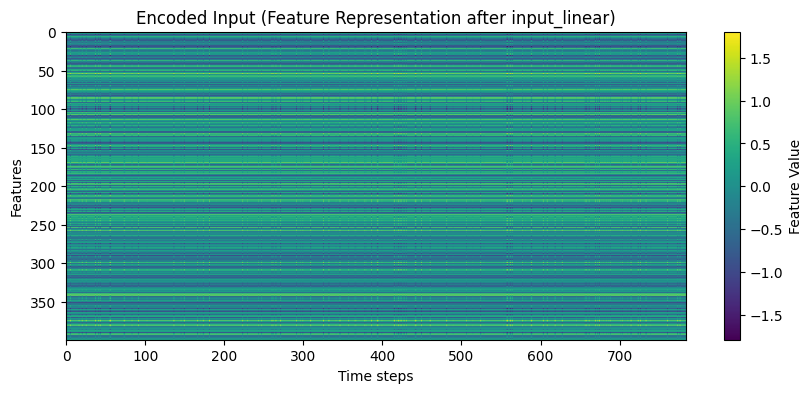

In [ ]:
import matplotlib.pyplot as plt

config = MambaConfig(
    d_model=400,
    n_layers=2,
    d_state=64,
    expand_factor=2,
    d_conv=4,
    pscan=True,
    use_fuse_clamp=True,
    input_dim=1,
    output_dim=10
    #inner_layernorms=True
)

model = SpikingMamba(config)


%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
model.eval()

(X_train, y_train), (X_test, y_test) = create_psmnist_datasets()
train_data = pSMNISTDataset(X_train, y_train)
test_data = pSMNISTDataset(X_test, y_test)

test_sample_idx = 0
x_test_sample = test_data[test_sample_idx]['inputs'].unsqueeze(0).to(device)
y_test_sample = test_data[test_sample_idx]['labels']

print("Selected test sample label:", y_test_sample.item())

activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu().numpy()
    return hook

model.input_linear.register_forward_hook(get_activation('input_encoding'))

first_block = model.layers[0].mixer
if hasattr(first_block, 'spike_sampler'):
    first_block.spike_sampler.register_forward_hook(get_activation('block0_spike_sampler'))

if hasattr(first_block, 'spike_mixer'):
    first_block.spike_mixer.register_forward_hook(get_activation('block0_spike_mixer'))

if hasattr(first_block, 'fuse_clamp') and first_block.fuse_clamp is not None:
    first_block.fuse_clamp.register_forward_hook(get_activation('block0_fuse_clamp'))

model.classification_head.register_forward_hook(get_activation('logits'))

with torch.no_grad():
    outputs = model(inputs=x_test_sample)

predicted_label = outputs.logits.argmax(dim=-1).item()
print("Predicted label:", predicted_label)


#input encoding
if 'input_encoding' in activations:
    encoded_input = activations['input_encoding'][0]
    plt.figure(figsize=(10,4))
    plt.title("Encoded Input (Feature Representation after input_linear)")
    plt.imshow(encoded_input.T, aspect='auto', cmap='viridis')
    plt.xlabel("Time steps")
    plt.ylabel("Features")
    plt.colorbar(label='Feature Value')
    plt.show()

#pike probabilities and sampled spikes
if 'block0_spike_sampler' in activations:
    sampled_spikes = activations['block0_spike_sampler'][0]
    plt.figure(figsize=(10,4))
    plt.title("Sampled Spikes at First Block")
    plt.imshow(sampled_spikes.T, aspect='auto', cmap='gray_r')
    plt.xlabel("Time steps")
    plt.ylabel("Neuron index")
    plt.colorbar(label='Spike (0/1)')
    plt.show()

#SpikeMixer out
if 'block0_spike_mixer' in activations:
    mixed_output = activations['block0_spike_mixer'][0]
    plt.figure(figsize=(10,4))
    plt.title("SpikeMixer Output")
    plt.imshow(mixed_output.T, aspect='auto', cmap='plasma')
    plt.xlabel("Time steps")
    plt.ylabel("Neuron index")
    plt.colorbar(label='Mixed Value')
    plt.show()

#FuseClamp out
if 'block0_fuse_clamp' in activations:
    fuse_output = activations['block0_fuse_clamp'][0]
    plt.figure(figsize=(10,4))
    plt.title("FuseClamp Output (Probabilities)")
    plt.imshow(fuse_output.T, aspect='auto', cmap='magma', vmin=0, vmax=1)
    plt.xlabel("Time steps")
    plt.ylabel("Neuron index")
    plt.colorbar(label='Clamped Probability')
    plt.show()

#logits
if 'logits' in activations:
    logits = activations['logits'][0]
    plt.figure(figsize=(6,4))
    plt.title("Final Logits")
    plt.bar(range(len(logits)), logits)
    plt.xlabel("Class index")
    plt.ylabel("Logit value")
    plt.show()

Test sample label: 7


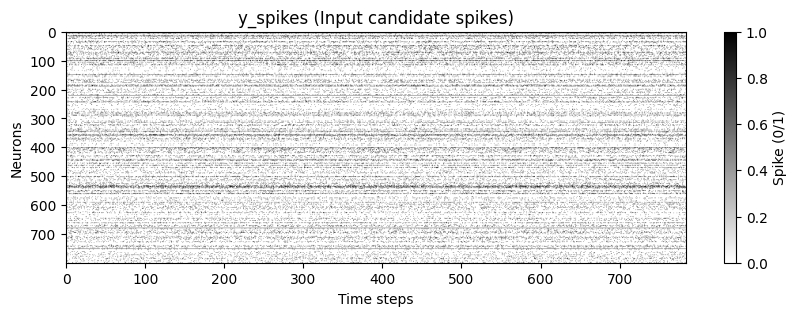

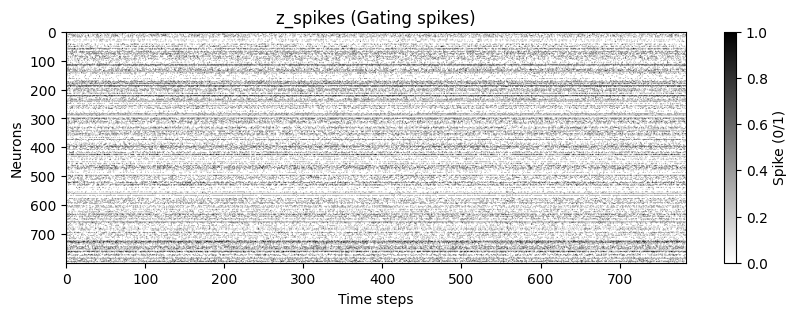

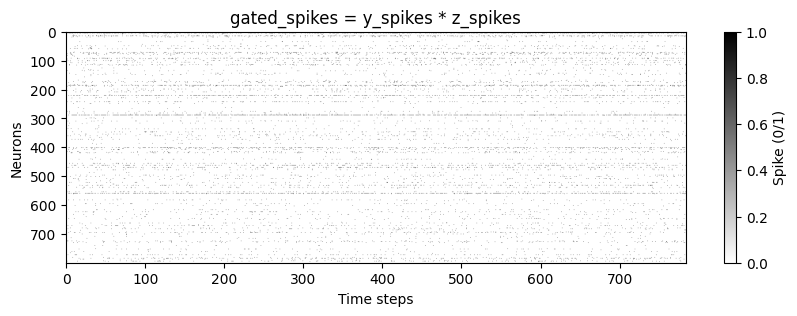

In [ ]:
model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

test_sample_idx = 0
x_test_sample = test_data[test_sample_idx]['inputs'].unsqueeze(0).to(device)
y_test_sample = test_data[test_sample_idx]['labels']
print("Test sample label:", y_test_sample.item())

activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu().numpy()
    return hook

first_block = model.layers[0].mixer
def hook_y_spikes(module, input, output):
    activations['y_spikes'] = module._debug_y_spikes.detach().cpu().numpy()

def hook_z_spikes(module, input, output):
    activations['z_spikes'] = module._debug_z_spikes.detach().cpu().numpy()

def hook_gated_spikes(module, input, output):
    activations['gated_spikes'] = module._debug_gated_spikes.detach().cpu().numpy()

first_block.register_forward_hook(hook_y_spikes)
first_block.register_forward_hook(hook_z_spikes)
first_block.register_forward_hook(hook_gated_spikes)

with torch.no_grad():
    outputs = model(inputs=x_test_sample)

y_spikes = activations['y_spikes'][0]
z_spikes = activations['z_spikes'][0]

#print(y_spikes)
#print(x_spikes)

gated_spikes = activations['gated_spikes'][0]
plt.figure(figsize=(10,3))
plt.title("y_spikes (Input candidate spikes)")
plt.imshow(y_spikes.T, aspect='auto', cmap='gray_r')
plt.xlabel('Time steps')
plt.ylabel('Neurons')
plt.colorbar(label='Spike (0/1)')
plt.show()

plt.figure(figsize=(10,3))
plt.title("z_spikes (Gating spikes)")
plt.imshow(z_spikes.T, aspect='auto', cmap='gray_r')
plt.xlabel('Time steps')
plt.ylabel('Neurons')
plt.colorbar(label='Spike (0/1)')
plt.show()

plt.figure(figsize=(10,3))
plt.title("gated_spikes = y_spikes * z_spikes")
plt.imshow(gated_spikes.T, aspect='auto', cmap='gray_r')
plt.xlabel('Time steps')
plt.ylabel('Neurons')
plt.colorbar(label='Spike (0/1)')
plt.show()

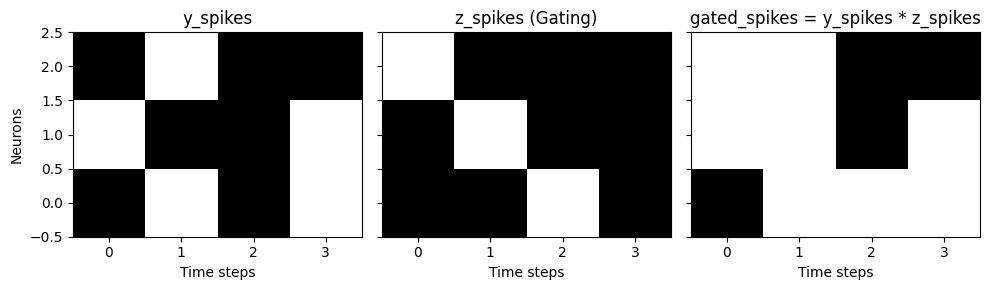

In [ ]:
time_steps = 4
neurons = 3

#this is a test example of how the gating mechanism works here:

#small spike pattern for y_spikes
#1 indicates a spike at that neuron and time step, 0 indicates no spike.
y_spikes = np.array([
    [1, 0, 1],  # time step 1
    [0, 1, 0],  # time step 2
    [1, 1, 1],  # time step 3
    [0, 0, 1]   # time step 4
])

#create a gating pattern z_spikes
# 1 means gate is open at that neuron/time, allowing y_spikes through.
# 0 means gate is closed, blocking y_spikes at that neuron/time.
z_spikes = np.array([
    [1, 1, 0],
    [1, 0, 1],
    [0, 1, 1],
    [1, 1, 1]
])

#compute the gated output as element-wise multiplication
gated_spikes = y_spikes * z_spikes

#visualize heatmapss
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=True)

#y_spikes visualization
axs[0].imshow(y_spikes.T, aspect='auto', cmap='gray_r')
axs[0].set_title("y_spikes")
axs[0].set_xlabel("Time steps")
axs[0].set_ylabel("Neurons")
axs[0].invert_yaxis()

#z_spikes visualization
axs[1].imshow(z_spikes.T, aspect='auto', cmap='gray_r')
axs[1].set_title("z_spikes (Gating)")
axs[1].set_xlabel("Time steps")
axs[1].invert_yaxis()

#gated_spikes visualization
axs[2].imshow(gated_spikes.T, aspect='auto', cmap='gray_r')
axs[2].set_title("gated_spikes = y_spikes * z_spikes")
axs[2].set_xlabel("Time steps")
axs[2].invert_yaxis()

plt.tight_layout()
plt.show()

# Training And Evaluation

## pSMNIST

In [ ]:
#torch.cuda.empty_cache()

### Training Run: pSMNIST

In [ ]:
import wandb
#wandb.login(key="")

import torch
from transformers import TrainingArguments, Trainer

seed = 42
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

wandb.init(project="spiking-mamba-psmnist-2")

(X_train, y_train), (X_test, y_test) = create_psmnist_datasets()
train_data = pSMNISTDataset(X_train, y_train)
test_data = pSMNISTDataset(X_test, y_test)

config = MambaConfig(
    d_model=400,
    n_layers=2,
    d_state=64,
    expand_factor=2,
    d_conv=4,
    pscan=True,
    use_fuse_clamp=True,
    input_dim=1,
    output_dim=10
    #inner_layernorms=True
)

model = SpikingMamba(config)
model.to("cuda")

#weight initialization
for name, param in model.named_parameters():
    if 'weight' in name and param.dim() > 1:
        torch.nn.init.kaiming_uniform_(param, a=math.sqrt(5))
    elif 'bias' in name:
        torch.nn.init.constant_(param, 0.0)

#training arguments from Mamba classifier as inspiration
training_args = TrainingArguments(
    output_dir="./spiking_mamba_psmnist_improved",
    per_device_train_batch_size=13,
    per_device_eval_batch_size=13,
    learning_rate=0.0001,
    num_train_epochs=20,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=400,
    save_steps=200,
    report_to="wandb",
    run_name="spiking_mamba_improved",
    push_to_hub=False,
    seed=seed,
    max_grad_norm=1.0,
)

trainer = MambaTrainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    processing_class=None,
    compute_metrics=compute_metrics
)

trainer.train()

wandb.finish()


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: donalds. Use `wandb login --relogin` to force relogin


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 41.9MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.23MB/s]


...

100%|██████████| 1.65M/1.65M [00:00<00:00, 11.0MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.83MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



Step,Training Loss,Validation Loss,Accuracy
210,2.294000,2.298627,0.097400


### Fine Tuning: pSMNIST

In [ ]:

#wandb.init(project="spiking-mamba-psmnist-2", name="finetune_lower_lr")


new_training_args = TrainingArguments(
    output_dir="./spiking_mamba_psmnist_reducedlr",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    learning_rate=0.00001,
    num_train_epochs=33,
    warmup_ratio=0.0,
    lr_scheduler_type="linear",
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    #report_to="wandb",
    push_to_hub=False,
    seed=42,
    max_grad_norm=1.0,
)

model_lower_lr = SpikingMamba(config)
model_lower_lr.to(device)

trainer_lower_lr = MambaTrainer(
    model=model_lower_lr,
    args=new_training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    compute_metrics=compute_metrics
)

#trainer_lower_lr.train(resume_from_checkpoint="/content/spiking_mamba_psmnist_reducedlr/checkpoint-27800")

#wandb.finish()


# Assessing Memory Footprint on pSMINIST

In [ ]:
import wandb

import torch
from transformers import TrainingArguments, Trainer

seed = 42
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

(X_train, y_train), (X_test, y_test) = create_psmnist_datasets()
train_data = pSMNISTDataset(X_train, y_train)
test_data = pSMNISTDataset(X_test, y_test)

config = MambaConfig(
    d_model=400,
    n_layers=2,
    d_state=64,
    expand_factor=2,
    d_conv=4,
    pscan=True,
    use_fuse_clamp=True,
    input_dim=1,
    output_dim=10
    #inner_layernorms=True
)

model = SpikingMamba(config)
model.to("cuda")

SpikingMamba(
  (input_linear): Linear(in_features=1, out_features=400, bias=True)
  (layers): ModuleList(
    (0-1): 2 x ResidualBlock(
      (mixer): SpikingMambaBlock(
        (in_proj): Linear(in_features=400, out_features=1600, bias=False)
        (conv1d): Conv1d(800, 800, kernel_size=(4,), stride=(1,), padding=(3,), groups=800)
        (x_proj): Linear(in_features=800, out_features=153, bias=False)
        (dt_proj): Linear(in_features=25, out_features=800, bias=True)
        (out_proj): Linear(in_features=800, out_features=400, bias=False)
        (spike_sampler): SpikeSampler()
        (spike_mixer): SpikeMixer(
          (mix): Linear(in_features=800, out_features=800, bias=False)
        )
        (fuse_clamp): FuseClamp(
          (bn): LayerNorm((800,), eps=1e-05, elementwise_affine=True)
        )
      )
      (norm): RMSNorm()
    )
  )
  (classification_head): MambaClassificationHead(
    (classification_head): Linear(in_features=400, out_features=10, bias=True)
  )
)

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print("total parameters in our model:", total_params)


total parameters in our model: 3607210


In [ ]:
(X_train, y_train), (X_test, y_test) = create_psmnist_datasets()
train_data = pSMNISTDataset(X_train, y_train)
test_data = pSMNISTDataset(X_test, y_test)

In [ ]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
criterion = nn.CrossEntropyLoss()
batch_size = 1
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

batch = next(iter(train_loader))
inputs, labels = batch["inputs"], batch["labels"]

inputs = inputs.to(device)
labels = labels.to(device)

torch.cuda.reset_peak_memory_stats(device=device)

outputs = model(inputs)

loss = criterion(outputs.logits, labels)
loss.backward()

peak_mem = torch.cuda.max_memory_allocated(device=device) / (1024**3)
print("Peak GPU memory usage:", peak_mem, "GB")

Peak GPU memory usage: 2.2371506690979004 GB


## Adding Task

In [ ]:
"""
This would have to be addapted for the current model architecture!

#evaluation metric for Adding Task is mse
mse_metric = evaluate.load("mse")
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    mse = ((predictions.squeeze() - labels)**2).mean()
    return {"mse": mse}

class MambaTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        input_values = inputs.pop("inputs")
        labels = inputs.pop('labels').float()
        outputs = model(inputs=input_values, labels=labels)
        loss = outputs.loss
        return (loss, outputs) if return_outputs else loss

    def save_model(self, output_dir = None, _internal_call = False):
        if output_dir is None:
            output_dir = self.args.output_dir
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        torch.save(self.model.state_dict(), f"{output_dir}/pytorch_model.bin")
        with open(f'{output_dir}/config.json', 'w') as f:
            json.dump(self.model.config.to_dict(), f)

train_data = AddingTaskDataset(size=20000, seq_len=50)
test_data = AddingTaskDataset(size=2000, seq_len=50)

config = MambaConfig(
    d_model=128,
    n_layers=3,
    d_state=32,
    expand_factor=2,
    d_conv=4,
    pscan=True,
    use_fuse_clamp=True,
    input_dim=2,
    output_dim=1
)

model = SpikingMamba(config)
model.to(device)

for name, param in model.named_parameters():
    if 'weight' in name and param.dim() > 1:
        torch.nn.init.kaiming_uniform_(param, a=math.sqrt(5))
    elif 'bias' in name:
        torch.nn.init.constant_(param, 0.0)

#wandb.init(project="spiking-mamba-addingtask", name="adding_task_run")

training_args = TrainingArguments(
    output_dir="./spiking_mamba_addingtask",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    learning_rate=0.001,
    num_train_epochs=10,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=200,
    save_steps=200,
    #report_to="wandb",
    push_to_hub=False,
    seed=42,
    max_grad_norm=1.0,
)

trainer = MambaTrainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    compute_metrics=compute_metrics
)

trainer.train()
#wandb.finish()

"""